In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error

## **Initial Setup**

* Load and define cleaned csv
* Define preset values for columns to be used in Linear Regression and Analysis

In [2]:
# Preset Vakues

filename = "CRMLS_0625-0626_clean.csv"

end_mnth = 6


main_cols = ["BedroomsTotal", "BathroomsTotalInteger", "LivingArea", "LotSizeSquareFeet",
             "DaysOnMarket", "YearBuilt", "PostalCode", "SaleMonth"]

extras = ["ViewYN", "FireplaceYN", "NewConstructionYN", "PoolPrivateYN"]
extra_cols = [a+"_True" for a in extras] + [a+"_False" for a in extras]

totals = main_cols+extra_cols

target = "ClosePrice"

In [3]:
def load_df(file=filename):
  """
  Takes a .csv filename or filepath
  Returns the DataFrame loaded from the csv
  """
  df = pd.read_csv(file, low_memory=False)
  df["CloseDate"] = pd.to_datetime(df["CloseDate"])     # Converts "CloseDate" values to datetime type
  return df

In [4]:
main_df = load_df()

# **Train, Test, Regression**

* Splits data into training and test sets
* Uses training in test sets to retrieve R2 scores of Linear Regression model

In [5]:
class W4_Regression():

  def __init__(self,df):
    self.df = df


  def test_train_split(self, end=end_mnth):
    """
    Takes a DataFrame
    Encodes "PropertyType" column
    Returns a defined training and test set for the DataFrame
    """
    yr_mo = []
    for i in self.df['CloseDate']:                                         # For each date in the "CloseDate" column
      yr, mo = i.year, i.month                                          # Define the year and month values of date i
      yr_mo.append([yr,mo])                                             # Append to "yr_mo" a list of date i's year and month
    te_set = [b for b in range(len(yr_mo)) if yr_mo[b] == [2026,end]]   # Define a list of row #s with date 06/2026
    te_rng = te_set[0::len(te_set)-1]                                 # Define a list of the first and last row in "te_set"
    tr, te = self.df[0:te_rng[0]], self.df[te_rng[0]:te_rng[1]]             # Define the training and test sets of the inputted df
    return tr, te


  def LinReg(self, tr, te, feat=totals, targ=target):
    """
    Takes a training DataFrame, test DataFrame, and feature and target values
    Returns R2 score of the Linear Regression
    """
    x_tr = tr[feat].values            # Define the x_train set values
    y_tr = tr[targ].values            # Define the y_train set values
    x_te = te[feat].values            # Define the x_test set values
    y_te = te[targ].values            # Define the y_test set values

    model = LinearRegression()        # Define Linear Regression model
    model.fit(x_tr, y_tr)             # Fit training data to model
    y_pred = model.predict(x_te)      # Models the predicted y values from x_test values

    return y_te, y_pred


  def log_transform(self, feat=main_cols, targ=target):
    log_df = self.df.copy()
    for col in feat+[targ]:
      new_col = []
      for val in log_df[col]:
        new_col.append(float(np.log(val)))
      log_df[col] = pd.DataFrame(new_col)
    return log_df


  def r2_eval(self, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)       # Computes the r2 score of y_test and the predicted y
    return r2

In [6]:
Week4 = W4_Regression(main_df)
train, test = Week4.test_train_split()

# **Feature to Target Analysis**

* Correlation Matrix to analyze commonalities between respective features and target
* Scatter Plots with respective features on x-axis against target on y-axis

In [7]:
# Correlation Matrix

def make_corr(df, targ):
  matrix = df.corr(numeric_only=True)         # Computes correlation matrix
  fig, ax = plt.subplots(figsize=(15,10))
  ax.imshow(matrix)                           # Plots visualization of correlation matrix

  vals = []
  for a in range(len(matrix)):
    for b in matrix:
      vals.append(round(float(matrix[b].iloc[a]),2))    # Appends the rounded correlation values of the matrix to list "vals"
  for c in range(len(matrix)):
    for d in range(len(matrix)):
      num = vals[d + len(matrix)*c]                     # Takes values by row and column
      if num >= .5:                                                               # If correlation is greater than or equal to 0.5
        txt = ax.text(x=(d-.28), y=(c+.05), s=num, fontsize=7.5, color="black")     # Add correlation value in black text
      else:                                                                       # Else
        txt = ax.text(x=(d-.28), y=(c+.05), s=num, fontsize=7.5, color="white")     # Add correlation value in white text
  lbls = [col for col in matrix]                                                  # Defines list of column titles as "lbls"
  t_lbl = ["" if i != targ else targ for i in matrix ]
  ax.set_yticks(range(len(lbls)), labels=lbls)                       # Labels y-ticks
  ax.set_xticks(range(len(t_lbl)), labels=t_lbl, rotation=45)                                    # Labels x-tick as target value
  ax.set_title("Correlation of Key Housing Features to ClosePrice\n")                            # Sets title for correlation matrix
  plt.show()

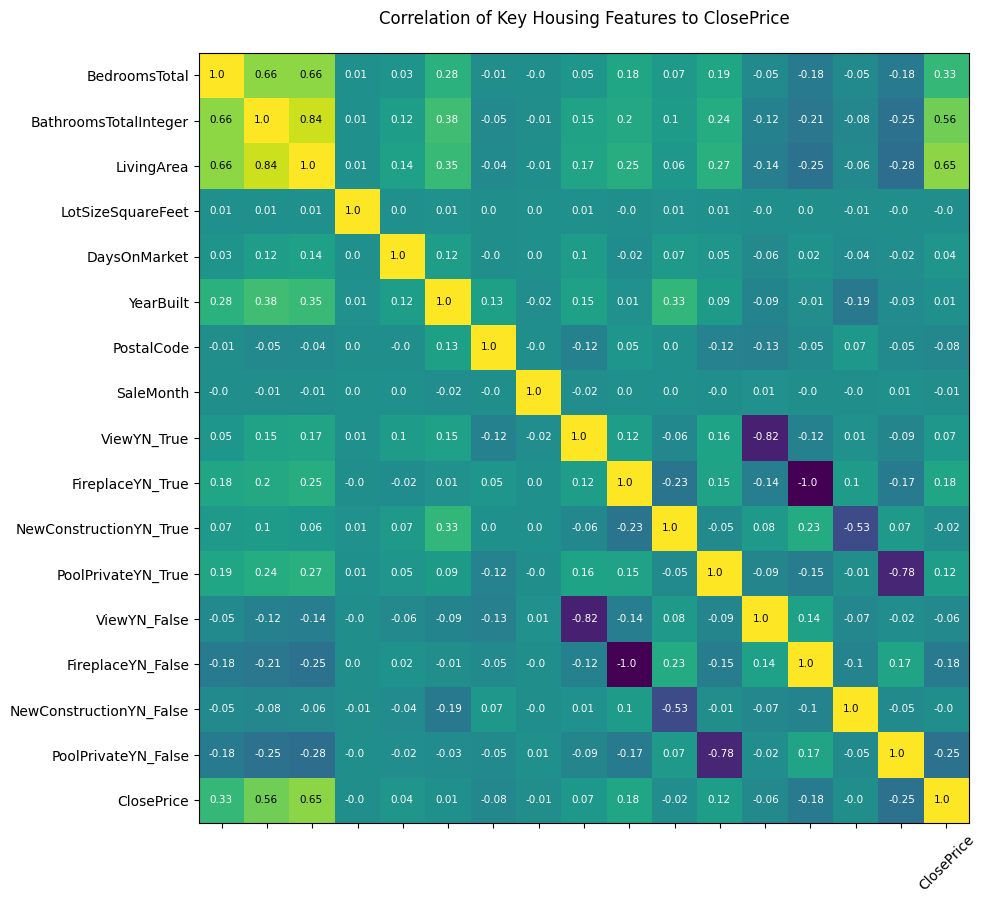

In [8]:
make_corr(main_df[(totals + [target])], target)

In [9]:
def map_vals(tr, te, feat=totals, targ=target):

  x_tr = tr[feat].values            # Define the x_train set values
  y_tr = tr[targ].values            # Define the y_train set values
  x_te = te[feat].values            # Define the x_test set values
  y_te = te[targ].values            # Define the y_test set values

  fig, ax = plt.subplots(1, len(feat), figsize=(15, 5))
  for i, feature in enumerate(feat):
      ax[i].scatter(x_tr[:, i], y_tr)
      ax[i].set_xlabel(feature)
      ax[i].set_title(f'{feature[0:5]} vs. Close$')
  plt.tight_layout()
  plt.show()

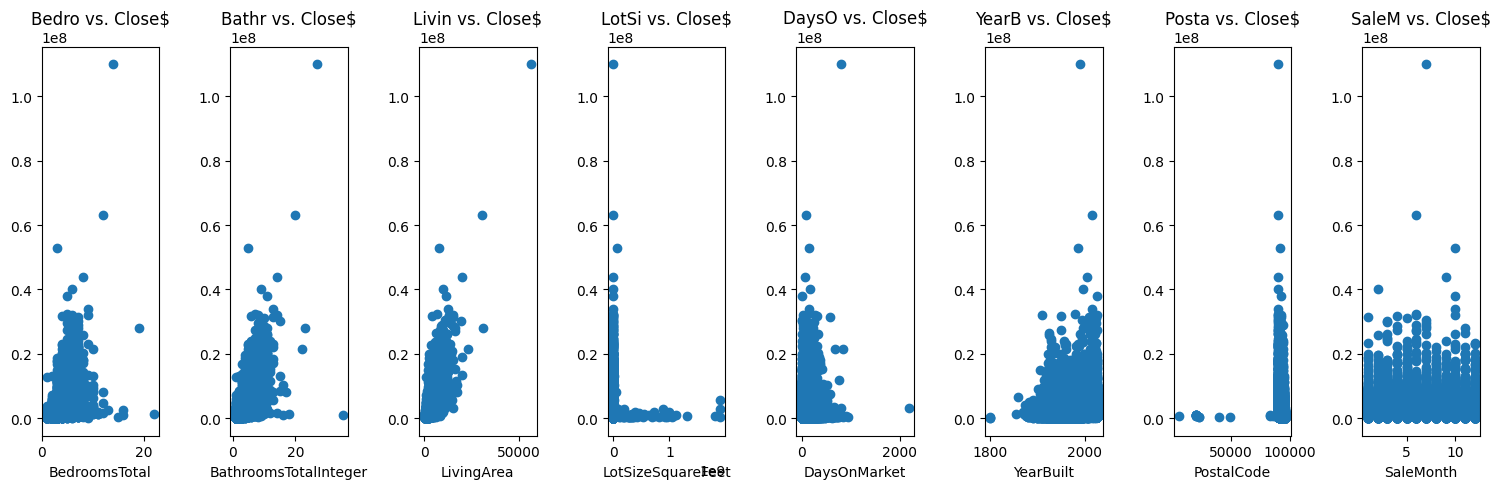

In [10]:
map_vals(train,test, main_cols)

In [8]:
def test_main():

  for col in totals:
    y_te, y_pr = Week4.LinReg(train, test, [col])
    r2s = Week4.r2_eval(y_te, y_pr)
    print(f"Correlation of {col}: \t\t {round(r2s,4)}")

In [9]:
if __name__ == "__main__":
  test_main()

Correlation of BedroomsTotal: 		 0.1121
Correlation of BathroomsTotalInteger: 		 0.2858
Correlation of LivingArea: 		 0.4064
Correlation of LotSizeSquareFeet: 		 -0.001
Correlation of DaysOnMarket: 		 -0.0009
Correlation of YearBuilt: 		 -0.0012
Correlation of PostalCode: 		 0.0041
Correlation of SaleMonth: 		 -0.0008
Correlation of ViewYN_True: 		 0.0025
Correlation of FireplaceYN_True: 		 0.0292
Correlation of NewConstructionYN_True: 		 -0.0004
Correlation of PoolPrivateYN_True: 		 0.0137
Correlation of ViewYN_False: 		 0.0016
Correlation of FireplaceYN_False: 		 0.0293
Correlation of NewConstructionYN_False: 		 -0.0011
Correlation of PoolPrivateYN_False: 		 0.0619


In [30]:
def main():

  r2_scores = []
  for col in totals:
    y_te, y_pr = Week4.LinReg(train, test, [col])
    r2s = Week4.r2_eval(y_te, y_pr)
    r2_scores.append(r2s)
  r2_lst = [[totals[i], r2_scores[i]] for i in range(len(r2_scores))]
  r2_lst = sorted(r2_lst, key=lambda x: x[1], reverse=True)

  r2_totals = []
  for i in range(1, len(r2_scores)):
    maximum = i
    cols = [r2_lst[a][0] for a in range(maximum)]
    y_te, y_pr = Week4.LinReg(train, test, cols)
    r2s = Week4.r2_eval(y_te, y_pr)
    print(f"Correlation of {cols}: \t\t {round(r2s,4)}")

    r2_totals.append([cols, r2s])
  r2_totals = sorted(r2_totals, key=lambda x: x[1], reverse=True)
  return r2_totals[0][0], r2_totals[0][1]

In [31]:
if __name__ == "__main__":
  main()

Correlation of ['LivingArea']: 		 0.4064
Correlation of ['LivingArea', 'BathroomsTotalInteger']: 		 0.4052
Correlation of ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal']: 		 0.4185
Correlation of ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal', 'PoolPrivateYN_False']: 		 0.4245
Correlation of ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal', 'PoolPrivateYN_False', 'FireplaceYN_False']: 		 0.4246
Correlation of ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal', 'PoolPrivateYN_False', 'FireplaceYN_False', 'FireplaceYN_True']: 		 0.4245
Correlation of ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal', 'PoolPrivateYN_False', 'FireplaceYN_False', 'FireplaceYN_True', 'PoolPrivateYN_True']: 		 0.4545
Correlation of ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal', 'PoolPrivateYN_False', 'FireplaceYN_False', 'FireplaceYN_True', 'PoolPrivateYN_True', 'PostalCode']: 		 0.464
Correlation of ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal', 'PoolPr

In [35]:
try_cols = ['LivingArea', 'BedroomsTotal', 'PoolPrivateYN_False', 'FireplaceYN_False', 'PoolPrivateYN_True', 'PostalCode', 'ViewYN_True', 'ViewYN_False', 'NewConstructionYN_True', 'SaleMonth', 'DaysOnMarket', 'LotSizeSquareFeet', 'NewConstructionYN_False']

y_te, y_pr = Week4.LinReg(train, test, try_cols)
r2 = Week4.r2_eval(y_te, y_pr)
print(f"{round(r2,4)}")

**Results 06/25-06/26**

Highest R2 Score:  **0.4759**
* Used all features in main_cols and extra_cols


**Results 05/25-05/26**

Highest R2 Score:  **0.3355**
* Used all features in main_cols and extra_cols
* Original main_cols list contained two additional columns:

  - "Levels" was cleaned and converted to integer format, but lowered the R2 score

  - "ParkingTotals" was evaluated, and ridded of outliers and improper values, but made no difference in R2score


# **Log Transform of Data**

I attempted to reintegrate "ParkingTotals" into the main columns, to see if the log transformation would make any impact on the r2 score this time.
* Removing 0 values from "ParkingTotals" led to lower R2 scores before the log transform

In [20]:
log_df = Week4.log_transform()
Wk4 = W4_Regression(log_df)
tr, te = Wk4.test_train_split()

In [28]:
def main():

  r2_scores = []
  for col in totals:
    y_te, y_pr = Wk4.LinReg(tr, te, [col])
    r2s = Wk4.r2_eval(y_te, y_pr)
    r2_scores.append(r2s)
  r2_lst = [[totals[i], r2_scores[i]] for i in range(len(r2_scores))]
  r2_lst = sorted(r2_lst, key=lambda x: x[1], reverse=True)

  r2_totals = []
  for i in range(1, len(r2_scores)):
    maximum = i
    cols = [r2_lst[a][0] for a in range(maximum)]
    y_te, y_pr = Wk4.LinReg(tr, te, cols)
    r2s = Wk4.r2_eval(y_te, y_pr)
    print(f"Correlation of {cols}: \t\t {round(r2s,4)}")

In [29]:
if __name__ == "__main__":
  main()

Correlation of ['LivingArea']: 		 0.343
Correlation of ['LivingArea', 'BathroomsTotalInteger']: 		 0.3465
Correlation of ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal']: 		 0.3458
Correlation of ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal', 'PoolPrivateYN_False']: 		 0.3711
Correlation of ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal', 'PoolPrivateYN_False', 'FireplaceYN_False']: 		 0.3781
Correlation of ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal', 'PoolPrivateYN_False', 'FireplaceYN_False', 'FireplaceYN_True']: 		 0.3782
Correlation of ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal', 'PoolPrivateYN_False', 'FireplaceYN_False', 'FireplaceYN_True', 'PoolPrivateYN_True']: 		 0.4175
Correlation of ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal', 'PoolPrivateYN_False', 'FireplaceYN_False', 'FireplaceYN_True', 'PoolPrivateYN_True', 'PostalCode']: 		 0.4443
Correlation of ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal', 'PoolPr

**Results 06/25-06/26**

Highest R2 Score:  **0.5538**
* Used all features in main_cols and extra_cols


**Results 05/25-05/26**

Highest R2 Score:  **0.5602**
* Used all features in main_cols and extra_cols
* Log Transform increased the R2 score by about 65.03%
